# Energy Price Prediction Pipeline

This notebook implements a modular machine learning pipeline for predicting 24-hour ahead energy price movements using news signals and energy market data.

## Pipeline Stages
1. **Setup & Configuration** - Initialize system and configure compute
2. **Data Ingestion** - Load news and energy data
3. **News Processing** - Extract text features and embeddings
4. **Feature Engineering** - Time-decay aggregation and UMAP
5. **Parameter Optimization** - Grid search over decay parameters
6. **Model Training** - Train XGBoost/LightGBM models
7. **Evaluation** - Performance assessment and statistical testing

## 1. Setup & Imports

In [1]:
# Add scripts directory to path
import sys
from pathlib import Path
import importlib

# Navigate to scripts directory
scripts_dir = Path('../scripts').resolve()
config_dir = Path('../config').resolve()
sys.path.insert(0, str(scripts_dir.parent))

# Standard imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Custom module imports
from config import pipeline_config as cfg
from config import model_config
from scripts import device_utils
from scripts import profiling
from scripts import data_ingestion
from scripts import feature_engineering as fe
from scripts import model_utils
from scripts import evaluation
from scripts import visualization

# Reload modules to pick up any changes
importlib.reload(device_utils)
importlib.reload(profiling)
importlib.reload(data_ingestion)
importlib.reload(fe)
importlib.reload(model_utils)
importlib.reload(evaluation)
importlib.reload(visualization)

# Configure display
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

print("✓ All modules imported and reloaded successfully")


✓ All modules imported and reloaded successfully


## 2. Configure Parameters

**Customize these parameters to tune the pipeline behavior:**

In [2]:
# ============================================================================
# CONFIGURABLE PARAMETERS - MODIFY THESE AS NEEDED
# ============================================================================

# Time-series parameters
FORECAST_HORIZON = cfg.FORECAST_HORIZON_HOURS  # 24 hours
LOOKBACK_WINDOW = cfg.DEFAULT_LOOKBACK_WINDOW  # 336 hours (2 weeks)
TIME_DECAY_LAMBDA = cfg.DEFAULT_DECAY_LAMBDA   # 0.05

# Target definition
SPREAD_DEADBAND = cfg.SPREAD_TARGET_DEADBAND   # 5.0 EUR/MWh

# Data splits
TRAIN_RATIO = cfg.TRAIN_RATIO  # 0.7
VAL_RATIO = cfg.VAL_RATIO      # 0.2
TEST_RATIO = cfg.TEST_RATIO    # 0.1

# Feature engineering
USE_UMAP = True  # Use UMAP for dimensionality reduction (False = PCA only)

# Cross-validation
N_CV_SPLITS = cfg.N_CV_SPLITS  # 5
CV_STEP_SIZE = cfg.CV_STEP_SIZE_HOURS  # 24

# Grid search ranges
LOOKBACK_WINDOWS = cfg.LOOKBACK_WINDOWS  # [168, 336, 504]
TIME_DECAY_LAMBDAS = cfg.TIME_DECAY_LAMBDAS  # [0.01, 0.05, 0.1]

# Random search
XGB_RANDOM_SEARCH_ITERS = cfg.XGB_RANDOM_SEARCH_ITERS  # 80 iterations by default

# Data paths (relative to data directory)
NEWS_PATH = "../data/german_news_v1.csv"
ENERGY_PATH = "../data/energy_data.csv"

print("✓ Configuration loaded")
print(f"  Forecast horizon: {FORECAST_HORIZON} hours")
print(f"  Lookback window: {LOOKBACK_WINDOW} hours")
print(f"  Time decay lambda: {TIME_DECAY_LAMBDA}")
print(f"  Spread deadband: {SPREAD_DEADBAND} EUR/MWh")

✓ Configuration loaded
  Forecast horizon: 24 hours
  Lookback window: 336 hours
  Time decay lambda: 0.05
  Spread deadband: 7.0 EUR/MWh


## 3. Initialize System & Detect Compute Device

In [3]:
# Detect available compute device (GPU/CPU)
device_config = device_utils.detect_compute_device(task='general', verbose=True)

print(f"\n✓ Using device: {device_config['description']}")
print(f"  Optimal batch size: {device_config['optimal_batch_size']}")

✓ CUDA detected: NVIDIA H200 (139.8 GB)
  Optimal batch size: 512
  XGBoost tree method: hist • device: cuda
  Parallel jobs: 95

✓ Using device: CUDA (NVIDIA H200)
  Optimal batch size: 512


## 4. Stage 1: Data Ingestion

In [4]:
with profiling.StageProfiler("Stage 1: Data Ingestion", device_config):
    ingestion_results = data_ingestion.run_ingestion_stage(
        news_path=NEWS_PATH,
        energy_path=ENERGY_PATH,
        min_timestamp=cfg.MIN_TIMESTAMP,
        news_sample=None,  # Set to integer for testing with smaller dataset
        forecast_horizon=FORECAST_HORIZON,
        spread_deadband=SPREAD_DEADBAND,
        random_state=cfg.RANDOM_STATE,
    )

news_df = ingestion_results['news_df']
energy_df = ingestion_results['energy_df']
master_df = ingestion_results['master_df']

print(f"\n✓ Data loaded successfully")
print(f"  News articles: {len(news_df)}")
print(f"  Energy records: {len(energy_df)}")
print(f"  Master records: {len(master_df)}")


[Stage ⏳] Stage 1: Data Ingestion — starting
News shape after filters: (94093, 4)
Energy telemetry shape: (33766, 5)
Baseline feature frame: (33574, 16)
[Stage ✅] Stage 1: Data Ingestion — completed in 0.79s
  CPU usage: 1.1% • IO wait: 0.00%
  Disk Δ: +0.0 MB read, +0.0 MB written
  GPU util: 0% • Mem util: 0% (0.59/140.40 GB)

✓ Data loaded successfully
  News articles: 94093
  Energy records: 33766
  Master records: 33574


### Inspect Data

In [5]:
# Check target distribution
print("Target distribution:")
print(master_df['spread_target_shift_24'].value_counts())
print(f"\nTarget distribution (%)")
print(master_df['spread_target_shift_24'].value_counts(normalize=True) * 100)

Target distribution:
spread_target_shift_24
-1.0    13659
 1.0    12785
 0.0     7130
Name: count, dtype: int64

Target distribution (%)
spread_target_shift_24
-1.0    40.683267
 1.0    38.080062
 0.0    21.236671
Name: proportion, dtype: float64


In [6]:
with profiling.StageProfiler("Stage 2A: Zero-Shot Topic Classification", device_config):
    embedding_results = fe.run_embedding_stage(
        news_df=news_df,
        candidate_labels=cfg.CANDIDATE_LABELS,
        hypothesis_template=cfg.HYPOTHESIS_TEMPLATE,
        device_config=device_config,
        batch_size=device_config['optimal_batch_size'],
        model_name=cfg.ZEROSHOT_MODEL,
        hierarchical_topic_groups=cfg.HIERARCHICAL_TOPIC_GROUPS,
        routing_settings=cfg.HIERARCHICAL_ROUTING_SETTINGS,
    )

news_df = embedding_results['news_df']

print(f"\n✓ Topic classification completed")
print(f"  Device used: {embedding_results['hf_device']}")
print(f"  Batch size: {embedding_results['batch_size']}")
if 'classification_stage1' in news_df.columns:
    print(f"  Stage-1 categories detected: {news_df['classification_stage1'].nunique()}")


[Stage ⏳] Stage 2A: Zero-Shot Topic Classification — starting


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/558M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/467 [00:00<?, ?B/s]

spm.model:   0%|          | 0.00/4.31M [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/173 [00:00<?, ?B/s]

Device set to use cuda:0


Processing 94092 texts with batch_size=512
Processing 11017 texts with batch_size=512
Processing 6864 texts with batch_size=512
Processing 2808 texts with batch_size=512
Processing 29141 texts with batch_size=512
Processing 2423 texts with batch_size=512
Processing 1568 texts with batch_size=512
Processing 43371 texts with batch_size=512
Processing 2914 texts with batch_size=512
Processing 4081 texts with batch_size=512


You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


Processing 9885 texts with batch_size=512
Processing 3428 texts with batch_size=512
Processing 658 texts with batch_size=512
Processing 360 texts with batch_size=512
Classification completed: 94093 articles processed
Articles classified as 'other': 22342 (23.7%)

Classification distribution:
classification
kein Bezug zu Energie, Wetter oder Finanzmärkten                                     22342
geopolitische Entspannung oder gelockerte Sanktionen mindern Versorgungsrisiken      21986
geopolitische Spannungen oder Sanktionen verschärfen die Energieversorgung           15372
steigende Zinsen oder hohe Inflation verschärfen die Marktlage                       11770
der Stromverbrauch in Deutschland steigt                                              5142
der Ausbau von LNG-Terminals, Pipelines oder Kraftwerken erhöht das Angebot           4703
Störungen oder Ausfälle bei Netzen oder Kraftwerken verringern das Angebot            2223
die Stromerzeugung aus Wind und Sonne fällt            

## 6. Stage 2B: Sentence Embeddings

In [7]:
with profiling.StageProfiler("Stage 2B: Sentence Embeddings", device_config):
    news_df = fe.compute_embeddings(
        news_df=news_df,
        device_config=device_config,
        model_name=cfg.EMBEDDING_MODEL,
        batch_size=device_config['optimal_batch_size'],
        show_progress=True,
        cache_dir=Path('../outputs/.cache/embeddings'),
    )

print(f"\n✓ Embeddings computed")
print(f"  Embedding dimension: {len(news_df.iloc[0]['embedding'])}")


[Stage ⏳] Stage 2B: Sentence Embeddings — starting


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Model converted to fp16 (half precision) for CUDA acceleration
CUDA optimizations enabled: batch_size=512
Using batch_size=512 for embedding computation on device=cuda


Batches:   0%|          | 0/184 [00:00<?, ?it/s]

Embeddings computed: shape (94093, 384)
[Stage ✅] Stage 2B: Sentence Embeddings — completed in 14.56s
  CPU usage: 1.6% • IO wait: 0.00%
  Disk Δ: +0.0 MB read, +1960.9 MB written
  GPU util: 0% • Mem util: 0% (2.21/140.40 GB)

✓ Embeddings computed
  Embedding dimension: 384


# Plot comprehensive EDA dashboard

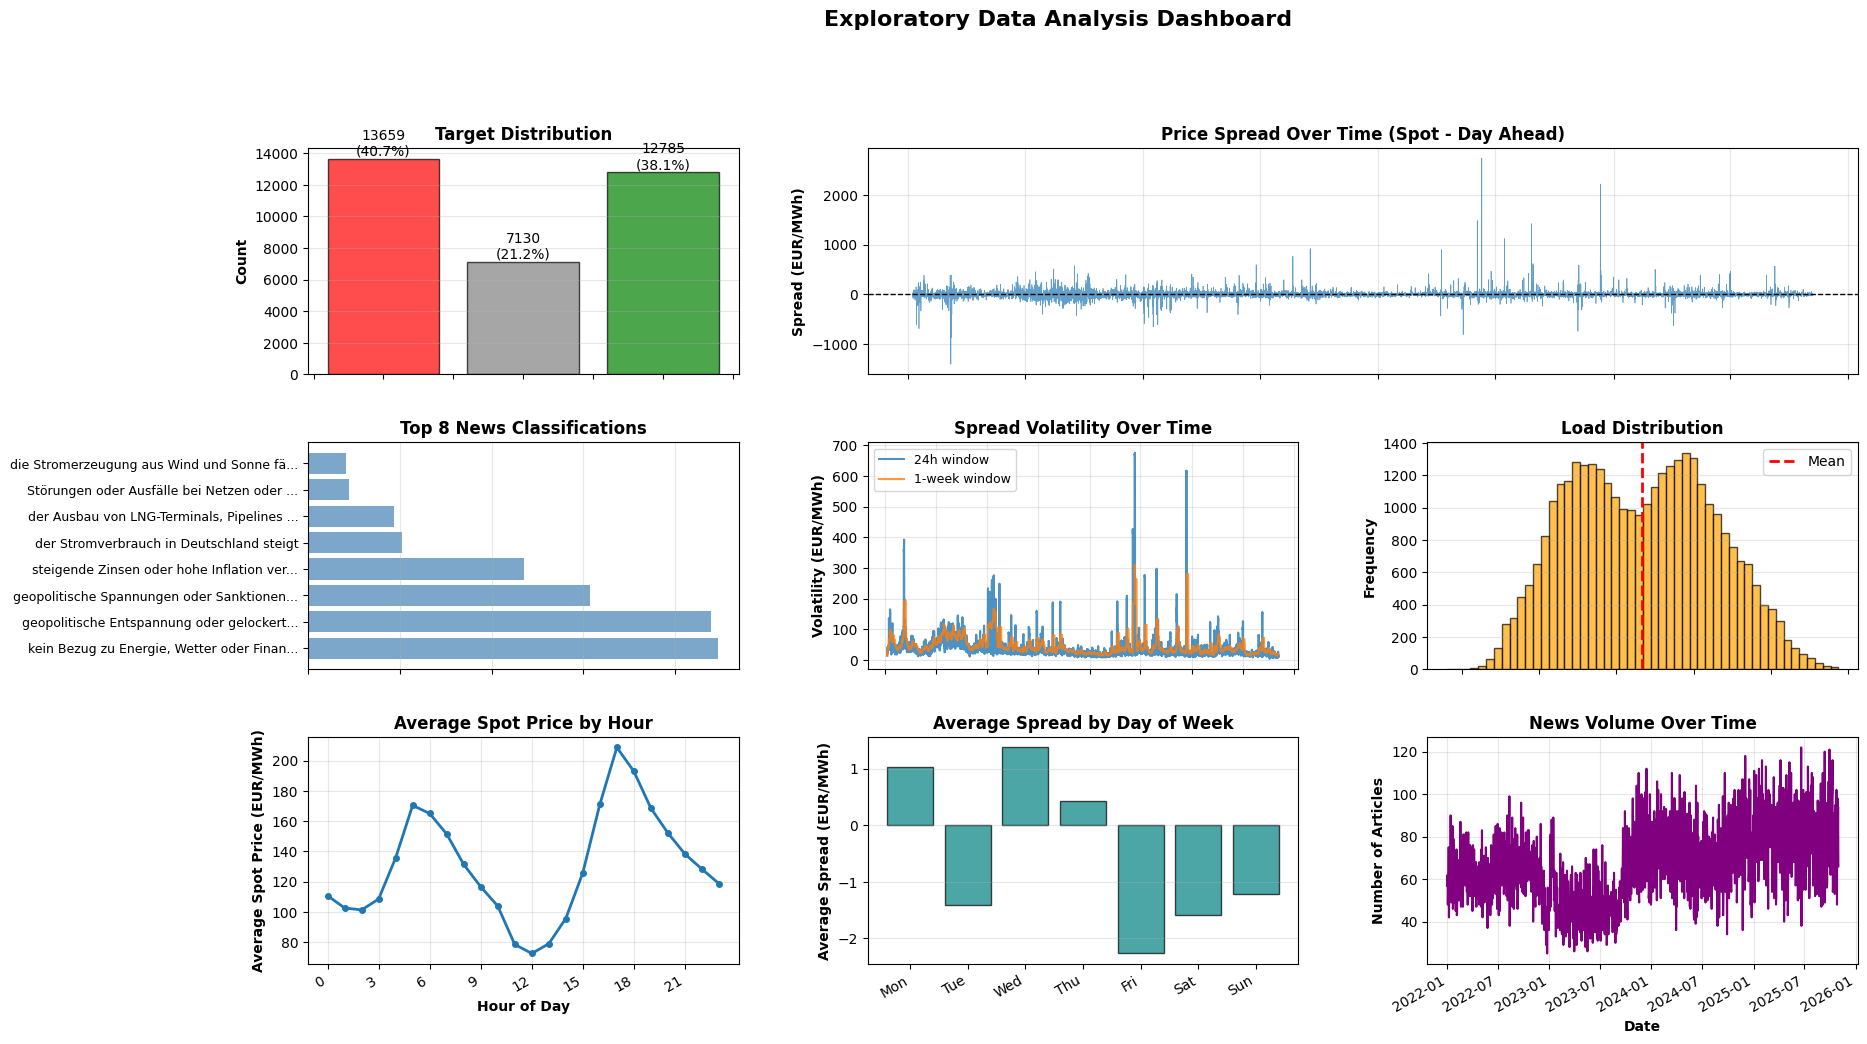

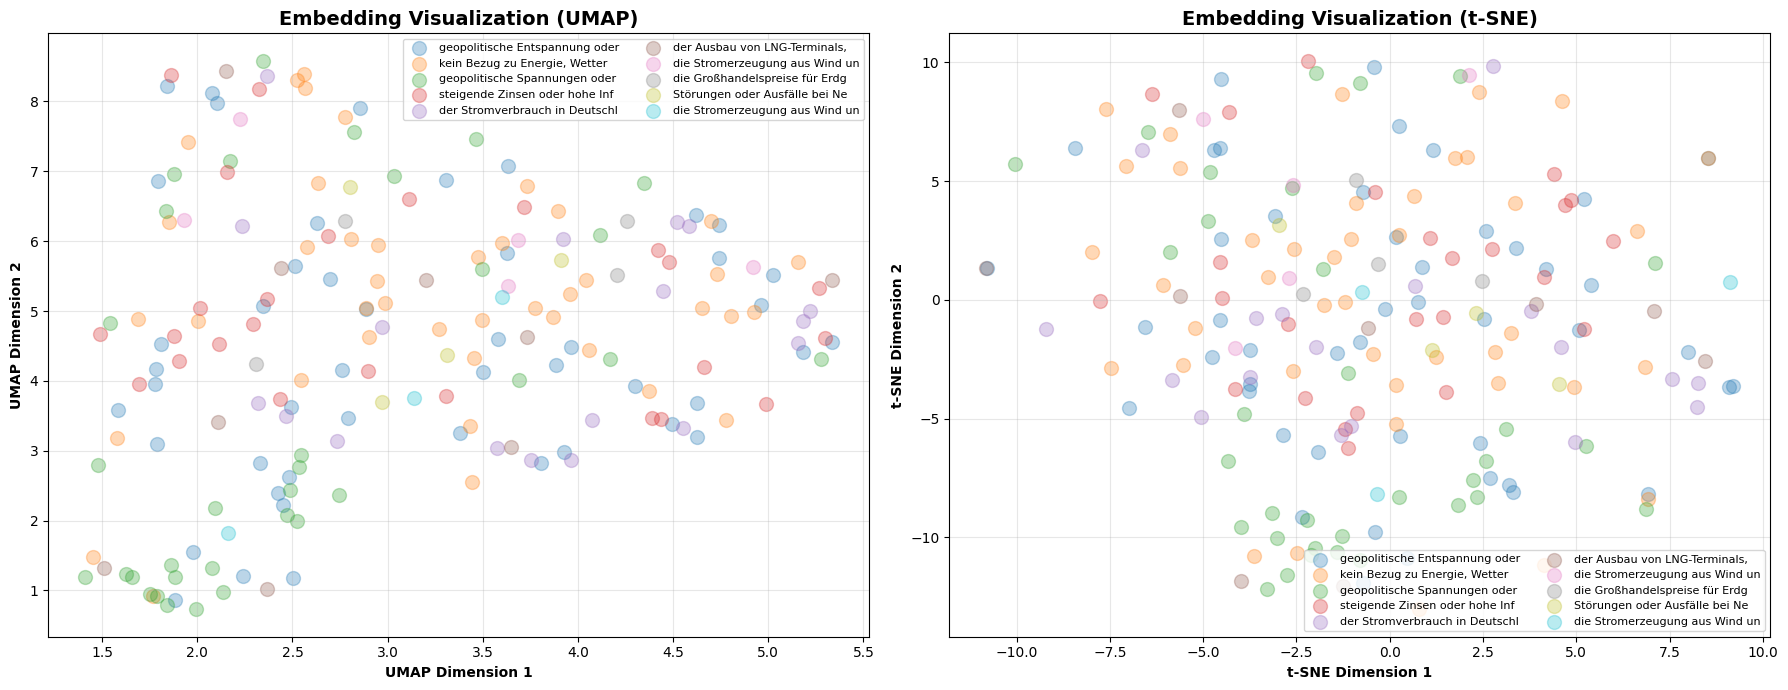

In [8]:
visualization.plot_eda_dashboard(master_df=master_df,news_df=news_df)
visualization.plot_embedding_quality(news_df=news_df, n_samples=200, perplexity=30)

## 7. Stage 3: Feature Engineering - Time-Decay Aggregation

In [9]:
with profiling.StageProfiler("Stage 3A: Time-Decay Feature Precomputation", device_config):
    feature_cache = fe.precompute_time_decay_feature_sets(
        news_df=news_df,
        master_df=master_df,
        lookback_windows=LOOKBACK_WINDOWS,
        decay_lambdas=TIME_DECAY_LAMBDAS,
        use_umap=USE_UMAP,
        random_state=cfg.RANDOM_STATE,
        device_config=device_config,
        verbose=True,
    )

print(f"\n✓ Time-decay feature cache built")
print(f"  Parameter combinations: {len(feature_cache)}")
print(f"  Sample keys: {list(feature_cache.keys())[:3]}")


[Stage ⏳] Stage 3A: Time-Decay Feature Precomputation — starting
Precomputing time-decayed features for 30 parameter combinations...
Parallelizing across parameter combinations using joblib (n_jobs=-1)...



[Parallel(n_jobs=-1)]: Using backend LokyBackend with 47 concurrent workers.


Embedding reduction backend: umap-learn
Embedding reduction backend: umap-learn
Embedding reduction backend: umap-learn
Embedding reduction backend: umap-learn
Embedding reduction backend: umap-learn


[Parallel(n_jobs=-1)]: Done   5 out of  30 | elapsed:  1.0min remaining:  5.1min


Embedding reduction backend: umap-learn
Embedding reduction backend: umap-learn
Embedding reduction backend: umap-learn
Embedding reduction backend: umap-learn


...

Embedding reduction backend: umap-learn
Embedding reduction backend: umap-learn
Embedding reduction backend: umap-learn
Embedding reduction backend: umap-learn


[Parallel(n_jobs=-1)]: Done  25 out of  30 | elapsed:  1.6min remaining:   18.9s


Embedding reduction backend: umap-learn
Embedding reduction backend: umap-learn
Embedding reduction backend: umap-learn
Embedding reduction backend: umap-learn
Embedding reduction backend: umap-learn


[Parallel(n_jobs=-1)]: Done  30 out of  30 | elapsed:  1.8min finished



✓ Completed precomputation of 30 parameter combinations
[Stage ✅] Stage 3A: Time-Decay Feature Precomputation — completed in 111.07s
  CPU usage: 9.8% • IO wait: 0.00%
  Disk Δ: +0.0 MB read, +275.0 MB written
  GPU util: 0% • Mem util: 0% (2.21/140.40 GB)

✓ Time-decay feature cache built
  Parameter combinations: 30
  Sample keys: [(24, 0.01), (24, 0.05), (24, 0.1)]


In [10]:
with profiling.StageProfiler("Stage 3B: Dataset Assembly", device_config):
    preprocessed_datasets = fe.assemble_time_decay_datasets(
        master_df=master_df,
        feature_cache=feature_cache,
        target_column=cfg.TARGET_COLUMN,
        train_ratio=TRAIN_RATIO,
        val_ratio=VAL_RATIO,
        test_ratio=TEST_RATIO,
        dataset_prefix="td_dataset",
    )

sample_params_key = next(iter(preprocessed_datasets))
sample_dataset = preprocessed_datasets[sample_params_key]

print(f"\n✓ Dataset assembly complete")
print(f"  Prepared datasets: {len(preprocessed_datasets)}")
print(
    f"  Sample dataset: {sample_dataset['dataset_name']} -> "
    f"train={len(sample_dataset['train_df'])}, "
    f"val={len(sample_dataset['val_df'])}, "
    f"test={len(sample_dataset['test_df'])}"
)


[Stage ⏳] Stage 3B: Dataset Assembly — starting
[Stage ✅] Stage 3B: Dataset Assembly — completed in 0.59s
  CPU usage: 0.6% • IO wait: 0.00%
  Disk Δ: +0.0 MB read, +0.2 MB written
  GPU util: 0% • Mem util: 0% (2.21/140.40 GB)

✓ Dataset assembly complete
  Prepared datasets: 30
  Sample dataset: td_dataset_lw24_dl0.01 -> train=23501, val=6714, test=3359


## 8. Stage 3C: Dataset Scaling & Summary

In [11]:
with profiling.StageProfiler("Stage 3C: Dataset Scaling", device_config):
    preprocessed_datasets = fe.scale_preprocessed_datasets(preprocessed_datasets)

sample_dataset = preprocessed_datasets[sample_params_key]
scaled_news_features = sample_dataset["scaled_news_features"]

print(f"\n✓ Dataset scaling complete")
print(f"  Scaled news features per dataset: {len(scaled_news_features)}")
print(f"  Sample scaled features: {scaled_news_features[:5]}")


[Stage ⏳] Stage 3C: Dataset Scaling — starting
[Stage ✅] Stage 3C: Dataset Scaling — completed in 0.80s
  CPU usage: 0.7% • IO wait: 0.00%
  Disk Δ: +0.0 MB read, +0.0 MB written
  GPU util: 0% • Mem util: 0% (2.21/140.40 GB)

✓ Dataset scaling complete
  Scaled news features per dataset: 34
  Sample scaled features: ['steigende Zinsen oder hohe Inflation verschärfen die Marktlage_scaled', 'der Ausbau von LNG-Terminals, Pipelines oder Kraftwerken erhöht das Angebot_scaled', 'der Stromverbrauch in Deutschland steigt_scaled', 'geopolitische Entspannung oder gelockerte Sanktionen mindern Versorgungsrisiken_scaled', 'sinkende Zinsen oder nachlassende Inflation beruhigen die Marktlage_scaled']


## 9. Stage 3D: Feature Selection with RidgeCV

In [12]:
# Define baseline (price + temporal) features
baseline_features = [
    "Spot Price", "Day Ahead Auction", "real_spread_abs",
    "price_lag_24", "price_lag_168", "Load", "load_lag_24", "load_lag_168",
    "hour", "day_of_week", "day_of_year", "week_of_year", "month",
]

# Get news feature definitions from sample dataset
topic_features = sample_dataset["topic_features"]
embedding_features = sample_dataset["embedding_features"]
news_features = sample_dataset["news_features"]
scaled_news_features = sample_dataset["scaled_news_features"]

print(f"✓ Feature sets defined")
print(f"  Baseline: {len(baseline_features)}, Topics: {len(topic_features)}, Embeddings: {len(embedding_features)}, Total news: {len(news_features)}")

# Run Ridge feature selection across parameter combinations
with profiling.StageProfiler("Stage 3D: Ridge Feature Selection", device_config):
    top_5_combinations = fe.grid_search_time_decay_params(
        preprocessed_datasets=preprocessed_datasets,
        baseline_features=baseline_features,
        target_column=cfg.TARGET_COLUMN,
        alphas=cfg.DEFAULT_ALPHAS,
        max_splits=cfg.N_CV_SPLITS,
    )

if top_5_combinations:
    best_params_key = top_5_combinations[0]["params_key"]
    best_dataset = preprocessed_datasets[best_params_key]
    print(f"\n✓ Top parameter combination: {best_dataset['dataset_name']} (lookback={top_5_combinations[0]['lookback_window']}h, lambda={top_5_combinations[0]['decay_lambda']})")
else:
    best_params_key = None
    best_dataset = None
    print("\n⚠ No valid parameter combinations identified. Review grid search configuration.")

✓ Feature sets defined
  Baseline: 13, Topics: 14, Embeddings: 20, Total news: 34

[Stage ⏳] Stage 3D: Ridge Feature Selection — starting
Grid searching 30 parameter combinations...
Using expanding-window RidgeCV confined to training splits (target: spread_target_shift_24)
Parallelizing evaluation across parameter combinations using joblib...



[Parallel(n_jobs=-1)]: Using backend LokyBackend with 47 concurrent workers.
[Parallel(n_jobs=-1)]: Done   5 out of  30 | elapsed:    1.1s remaining:    5.5s
[Parallel(n_jobs=-1)]: Done   9 out of  30 | elapsed:    1.2s remaining:    2.8s
[Parallel(n_jobs=-1)]: Done  13 out of  30 | elapsed:    1.3s remaining:    1.6s
[Parallel(n_jobs=-1)]: Done  17 out of  30 | elapsed:    4.8s remaining:    3.7s
[Parallel(n_jobs=-1)]: Done  21 out of  30 | elapsed:    4.8s remaining:    2.1s
[Parallel(n_jobs=-1)]: Done  25 out of  30 | elapsed:    4.9s remaining:    1.0s
[Parallel(n_jobs=-1)]: Done  30 out of  30 | elapsed:    4.9s finished


TOP 5 PARAMETER COMBINATIONS:
1. dataset=td_dataset_lw168_dl0.01 | lookback=168h | lambda=0.01 | alpha=1000.0000 | Val Accuracy=0.438 | Val Macro-F1=0.336
2. dataset=td_dataset_lw504_dl0.05 | lookback=504h | lambda=0.05 | alpha=1000.0000 | Val Accuracy=0.434 | Val Macro-F1=0.330
3. dataset=td_dataset_lw24_dl0.01 | lookback=24h | lambda=0.01 | alpha=1000.0000 | Val Accuracy=0.433 | Val Macro-F1=0.332
4. dataset=td_dataset_lw168_dl0.25 | lookback=168h | lambda=0.25 | alpha=1000.0000 | Val Accuracy=0.431 | Val Macro-F1=0.323
5. dataset=td_dataset_lw72_dl0.25 | lookback=72h | lambda=0.25 | alpha=3.1623 | Val Accuracy=0.431 | Val Macro-F1=0.322
[Stage ✅] Stage 3D: Ridge Feature Selection — completed in 5.05s
  CPU usage: 9.4% • IO wait: 0.00%
  Disk Δ: +0.0 MB read, +3.8 MB written
  GPU util: 0% • Mem util: 0% (2.21/140.40 GB)

✓ Top parameter combination: td_dataset_lw168_dl0.01 (lookback=168h, lambda=0.01)


## 10. Stage 3E: Summarise Ridge Results

In [13]:
# Display top 5 Ridge parameter combinations
if top_5_combinations:
    top_5_summary = pd.DataFrame([{
        "dataset_name": res["dataset_name"],
        "lookback_window": res["lookback_window"],
        "decay_lambda": res["decay_lambda"],
        "alpha": res["best_alpha"],
        "val_accuracy": res["val_accuracy"],
        "val_macro_f1": res["val_macro_f1"],
    } for res in top_5_combinations])
    display(top_5_summary)
else:
    print("No RidgeCV results available to summarise.")

,dataset_name,lookback_window,decay_lambda,alpha,val_accuracy,val_macro_f1
0,td_dataset_lw168_dl0.01,168,0.01,1000.000000,0.437891,0.336278
1,td_dataset_lw504_dl0.05,504,0.05,1000.000000,0.434018,0.330075
2,td_dataset_lw24_dl0.01,24,0.01,1000.000000,0.433274,0.332157
3,td_dataset_lw168_dl0.25,168,0.25,1000.000000,0.431486,0.322832
4,td_dataset_lw72_dl0.25,72,0.25,3.162278,0.431040,0.322478


## 11. Stage 4: Model Training - XGBoost with Random Search

**Note:** This section demonstrates XGBoost training with hyperparameter tuning (default `n_iter=80`). Adjust `n_iter` and CV parameters based on your computational resources.

In [14]:
with profiling.StageProfiler("Stage 4: XGBoost Random Search", device_config):
    xgb_results = model_utils.train_xgb_candidates(
        top_combinations=top_5_combinations if top_5_combinations else [],
        preprocessed_datasets=preprocessed_datasets,
        baseline_features=baseline_features,
        target_column=cfg.TARGET_COLUMN,
        param_distributions=cfg.XGB_PARAM_DISTRIBUTIONS,
        n_iter=XGB_RANDOM_SEARCH_ITERS,
        random_state=cfg.RANDOM_STATE,
        n_splits=cfg.DEFAULT_EXPANDING_SPLITS,
        step_size=cfg.DEFAULT_EXPANDING_STEP,
        min_train_size=cfg.DEFAULT_MIN_TRAIN_SIZE,
        device_config=device_config,
        fallback_params_key=sample_params_key if not top_5_combinations else None,
        fallback_dataset=sample_dataset if not top_5_combinations else None
    )

# Extract results
xgb_tuning_runs = xgb_results["tuning_runs"]
xgb_best_models = xgb_results["best_models"]
xgb_feature_columns = xgb_results["feature_columns"]
xgb_label_encoders = xgb_results["label_encoders"]
best_xgb_run = xgb_results["best_run"]
best_xgb_params_key = xgb_results["best_params_key"]
best_xgb_model = xgb_results["best_model"]
best_xgb_feature_columns = xgb_results["best_feature_columns"]
best_xgb_label_encoder = xgb_results["best_label_encoder"]
best_dataset = xgb_results["best_dataset"]


[Stage ⏳] Stage 4: XGBoost Random Search — starting
Training XGBoost with 3 classes: [-1  0  1]
Running RandomizedSearchCV with CUDA-accelerated XGBoost (serial CV fits).
Fitting 4 folds for each of 80 candidates, totalling 320 fits
#1 td_dataset_lw168_dl0.01 → CV F1=0.289, Val Acc=0.438, Val Macro-F1=0.339
Training XGBoost with 3 classes: [-1  0  1]
Running RandomizedSearchCV with CUDA-accelerated XGBoost (serial CV fits).
Fitting 4 folds for each of 80 candidates, totalling 320 fits
#2 td_dataset_lw504_dl0.05 → CV F1=0.274, Val Acc=0.463, Val Macro-F1=0.360
Training XGBoost with 3 classes: [-1  0  1]
Running RandomizedSearchCV with CUDA-accelerated XGBoost (serial CV fits).
Fitting 4 folds for each of 80 candidates, totalling 320 fits
#3 td_dataset_lw24_dl0.01 → CV F1=0.293, Val Acc=0.461, Val Macro-F1=0.377
Training XGBoost with 3 classes: [-1  0  1]
Running RandomizedSearchCV with CUDA-accelerated XGBoost (serial CV fits).
Fitting 4 folds for each of 80 candidates, totalling 320 f

In [15]:
# Threshold tuning for XGBoost positive class (label = 1)
from sklearn.metrics import f1_score

xgb_positive_class_label = 1
class_indices = np.where(best_xgb_label_encoder.classes_ == xgb_positive_class_label)[0]
if len(class_indices) == 0:
    raise ValueError(
        f"Positive class label {xgb_positive_class_label} not found in XGBoost label encoder classes {best_xgb_label_encoder.classes_}."
    )
xgb_positive_class_index = int(class_indices[0])

X_val_xgb = best_dataset["val_df"][best_xgb_feature_columns].fillna(0)
y_val_xgb = best_xgb_label_encoder.transform(
    best_dataset["val_df"][cfg.TARGET_COLUMN].astype(int)
)
val_proba_xgb = best_xgb_model.predict_proba(X_val_xgb)

xgb_opt_threshold, xgb_opt_metric = model_utils.optimize_classification_threshold(
    y_true=y_val_xgb,
    y_proba=val_proba_xgb,
    metric="f1",
    class_of_interest=xgb_positive_class_index,
)

xgb_val_pred_threshold = model_utils.apply_threshold_to_probabilities(
    y_proba=val_proba_xgb,
    threshold=xgb_opt_threshold,
    class_of_interest=xgb_positive_class_index,
)

xgb_val_macro_f1_threshold = f1_score(
    y_val_xgb,
    xgb_val_pred_threshold,
    average="macro",
    zero_division=0,
)

print("✓ XGBoost threshold tuning complete")
print(f"  Positive class label: {xgb_positive_class_label} → encoder index {xgb_positive_class_index}")
print(f"  Optimal threshold (validation): {xgb_opt_threshold:.3f}")
print(f"  Validation Macro-F1 (thresholded): {xgb_val_macro_f1_threshold:.3f}")



THRESHOLD OPTIMIZATION
Metric: f1
Optimised class index: 2 (of 3 classes)
Optimal threshold: 0.250
Best f1: 0.5531
Default (0.5) f1: 0.2980

✓ XGBoost threshold tuning complete
  Positive class label: 1 → encoder index 2
  Optimal threshold (validation): 0.250
  Validation Macro-F1 (thresholded): 0.303



COMPUTING LEARNING CURVES FOR XGBOOST 3-CLASS CLASSIFIER
This may take a few minutes...


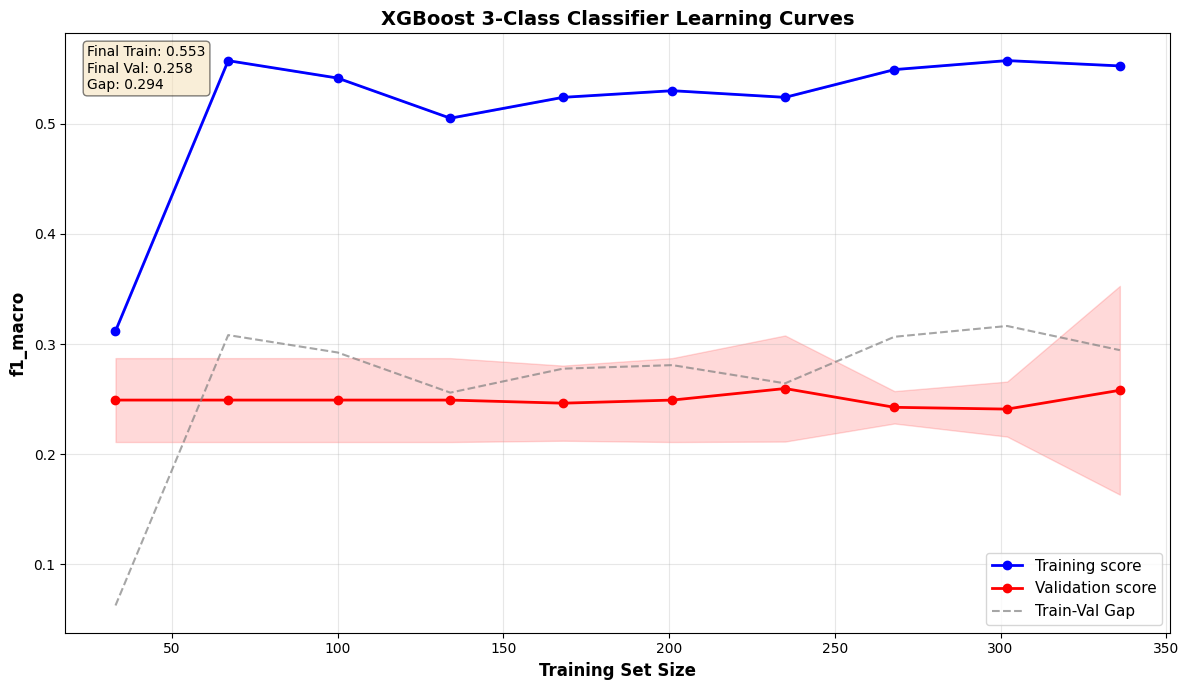

✓ Learning curves complete
  Final training score: 0.5525
  Final validation score: 0.2581
  Train-val gap: 0.2945
  ⚠ Warning: Large gap suggests overfitting



In [16]:
# Learning curves for best XGBoost model
if best_xgb_run is not None:
    from sklearn.base import clone
    
    # Recreate a fresh estimator with the same parameters
    xgb_for_learning_curve = clone(best_xgb_model)
    xgb_for_learning_curve.set_params(**best_xgb_run['best_params'])
    
    # Create CV splitter
    lc_cv = model_utils.ExpandingWindowSplitter(
        n_splits=3,  # Use fewer splits for speed
        step_size=cfg.DEFAULT_EXPANDING_STEP,
        min_train_size=cfg.DEFAULT_MIN_TRAIN_SIZE,
    )
    
    # Prepare data with 3-class encoding
    X_train_xgb = best_dataset['train_df'][best_xgb_feature_columns].fillna(0)
    y_train_xgb = best_xgb_label_encoder.transform(
        best_dataset['train_df'][cfg.TARGET_COLUMN].astype(int)
    )
    
    visualization.plot_learning_curves(
        model=xgb_for_learning_curve,
        X_train=X_train_xgb,
        y_train=y_train_xgb,
        cv_splitter=lc_cv,
        scoring='f1_macro',
        model_name='XGBoost 3-Class Classifier'
    )

## 12. Stage 5: Model Evaluation

In [17]:
from sklearn.metrics import accuracy_score, f1_score

if best_xgb_model is None:
    raise RuntimeError("XGBoost model not available. Please rerun Stage 4.")

# Prepare test data
test_dataset = best_dataset
X_test = test_dataset["test_df"][best_xgb_feature_columns].fillna(0)
y_test_raw = test_dataset["test_df"][cfg.TARGET_COLUMN].astype(int)
y_test = best_xgb_label_encoder.transform(y_test_raw)

# Evaluate model probabilities
y_pred_proba = best_xgb_model.predict_proba(X_test)
y_pred_default = np.argmax(y_pred_proba, axis=1)

xgb_test_pred_threshold = model_utils.apply_threshold_to_probabilities(
    y_proba=y_pred_proba,
    threshold=xgb_opt_threshold,
    class_of_interest=xgb_positive_class_index,
)

# Metrics without and with threshold tuning
xgb_test_accuracy_default = accuracy_score(y_test, y_pred_default)
xgb_test_macro_f1_default = f1_score(y_test, y_pred_default, average="macro", zero_division=0)

test_accuracy = accuracy_score(y_test, xgb_test_pred_threshold)
test_macro_f1 = f1_score(y_test, xgb_test_pred_threshold, average="macro", zero_division=0)

print(f"\n✓ XGBoost Test Evaluation (3-class)")
print(f"  Default (argmax) → Acc={xgb_test_accuracy_default:.4f}, Macro-F1={xgb_test_macro_f1_default:.4f}")
print(f"  Thresholded      → Acc={test_accuracy:.4f}, Macro-F1={test_macro_f1:.4f}")

# Display detailed class-wise metrics for thresholded predictions
model_utils.print_class_wise_metrics(
    y_true=y_test,
    y_pred=xgb_test_pred_threshold,
    label_encoder=best_xgb_label_encoder,
    dataset_name="XGBoost Test Set (Thresholded)"
)


✓ XGBoost Test Evaluation (3-class)
  Default (argmax) → Acc=0.4290, Macro-F1=0.3704
  Thresholded      → Acc=0.3620, Macro-F1=0.2351

CLASS-WISE METRICS: XGBoost Test Set (Thresholded)

Confusion Matrix:
[[ 124   10 1041]
 [  69   10  965]
 [  52    6 1082]]

Per-Class Recall:
  Class -1: 0.106 (124/1175)
  Class 0: 0.010 (10/1044)
  Class 1: 0.949 (1082/1140)

Classification Report:
              precision    recall  f1-score   support

          -1       0.51      0.11      0.17      1175
           0       0.38      0.01      0.02      1044
           1       0.35      0.95      0.51      1140

    accuracy                           0.36      3359
   macro avg       0.41      0.35      0.24      3359
weighted avg       0.42      0.36      0.24      3359


Predictions per class:
  Class -1: 245 predictions (7.3%)
  Class 0: 26 predictions (0.8%)
  Class 1: 3088 predictions (91.9%)



## 13. Visualizations

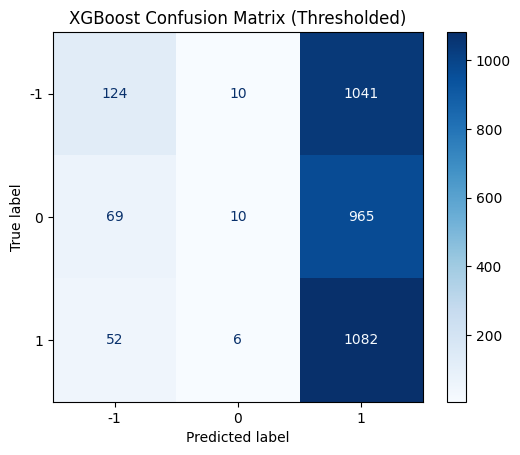

In [18]:
# Confusion matrix (3-class)
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, xgb_test_pred_threshold)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=best_xgb_label_encoder.classes_
)
disp.plot(cmap='Blues', values_format='d')
plt.title('XGBoost Confusion Matrix (Thresholded)')
plt.show()


/workspace/scripts/visualization.py:108: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


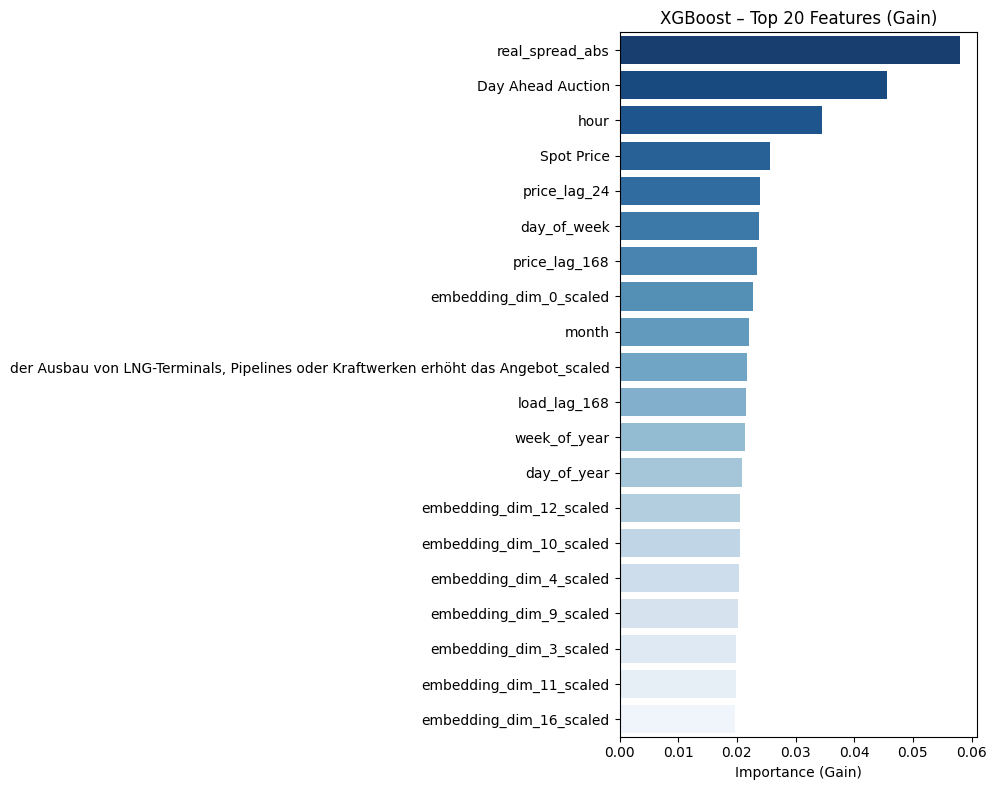

In [19]:
# Feature importance
importance_df = visualization.plot_feature_importance(
    model=best_xgb_model,
    feature_names=best_xgb_feature_columns,
    model_name="XGBoost",
    top_n=20
)

## 14. Stage 6: LightGBM Signal Modelling


In [20]:
if best_xgb_model is None or best_dataset is None:
    raise RuntimeError("XGBoost model and dataset must be available before training LightGBM.")

# Prepare datasets for LightGBM using helper function
lgbm_prep = model_utils.prepare_lgbm_datasets(
    best_xgb_model=best_xgb_model,
    best_dataset=best_dataset,
    best_xgb_feature_columns=best_xgb_feature_columns,
    baseline_features=baseline_features,
    target_column=cfg.TARGET_COLUMN,
    prediction_prefix="xgb"
)

signal_train_df = lgbm_prep["train_df"]
signal_val_df = lgbm_prep["val_df"]
signal_test_df = lgbm_prep["test_df"]
signal_feature_columns = lgbm_prep["signal_feature_columns"]
baseline_feature_columns = lgbm_prep["baseline_feature_columns"]
xgb_feature_names = lgbm_prep["xgb_feature_names"]

print("✓ Prepared LightGBM datasets with XGBoost features")
print(f"  Signal feature count: {len(signal_feature_columns)}")
print(f"  Baseline feature count: {len(baseline_feature_columns)}")
print(f"  XGBoost features added: {xgb_feature_names}")


✓ Prepared LightGBM datasets with XGBoost features
  Signal feature count: 50
  Baseline feature count: 13
  XGBoost features added: ['xgb_prob_class0', 'xgb_prob_class1', 'xgb_pred']


In [21]:
# Prepare and encode targets for LightGBM
target_prep = model_utils.prepare_lgbm_targets(
    train_df=signal_train_df,
    val_df=signal_val_df,
    test_df=signal_test_df,
    target_column=cfg.TARGET_COLUMN
)

y_train_signal = target_prep["y_train"]
y_val_signal = target_prep["y_val"]
y_test_signal = target_prep["y_test"]
label_encoder = target_prep["label_encoder"]

print("✓ Encoded LightGBM targets")
print(
    "  Classes:",
    dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))
)


✓ Encoded LightGBM targets
  Classes: {np.int64(-1): np.int64(0), np.int64(0): np.int64(1), np.int64(1): np.int64(2)}


In [22]:
# Configure device for LightGBM
lgbm_device_config = device_utils.detect_compute_device(task='training', verbose=True)
print(f"LightGBM device: {lgbm_device_config.get('description')} • backend={lgbm_device_config.get('lgbm_device', lgbm_device_config.get('device'))} • jobs={lgbm_device_config.get('n_jobs')}")

# Train both signal and baseline LightGBM models (class imbalance handled via is_unbalance=True and class_weight='balanced')
with profiling.StageProfiler("Stage 6: LightGBM Signal & Baseline Models", device_config):
    lgbm_results = model_utils.train_lightgbm_pair(
        signal_train_df=signal_train_df,
        signal_val_df=signal_val_df,
        signal_test_df=signal_test_df,
        signal_feature_columns=signal_feature_columns,
        baseline_feature_columns=baseline_feature_columns,
        y_train=y_train_signal,
        y_val=y_val_signal,
        y_test=y_test_signal,
        label_encoder=label_encoder,
        param_grid=model_config.LIGHTGBM_PARAM_GRID,
        n_cv_splits=cfg.N_CV_SPLITS,
        cv_step_size=cfg.DEFAULT_EXPANDING_STEP,
        cv_min_train_size=cfg.DEFAULT_MIN_TRAIN_SIZE,
        device_config=lgbm_device_config,
        random_state=cfg.RANDOM_STATE
    )

# Extract trained models and artifacts
signal_best_lgbm = lgbm_results["signal_model"]
baseline_best_lgbm = lgbm_results["baseline_model"]
signal_column_rename_map = lgbm_results["signal_column_rename_map"]
baseline_column_rename_map = lgbm_results["baseline_column_rename_map"]
lgbm_artifacts = lgbm_results["evaluation"]
signal_test_pred = lgbm_artifacts["signal"]["test_pred"]
signal_test_proba = lgbm_artifacts["signal"]["test_proba"]
baseline_test_pred = lgbm_artifacts["baseline"]["test_pred"]
baseline_test_proba = lgbm_artifacts["baseline"]["test_proba"]
test_signal_X = lgbm_artifacts["signal"]["test_X"]
test_baseline_X = lgbm_artifacts["baseline"]["test_X"]

✓ CUDA detected: NVIDIA H200 (139.8 GB)
  Optimal batch size: 512
  XGBoost tree method: hist • device: cuda
  Parallel jobs: 95
LightGBM device: CUDA (NVIDIA H200) • backend=gpu • jobs=95

[Stage ⏳] Stage 6: LightGBM Signal & Baseline Models — starting

TRAINING LIGHTGBM SIGNAL & BASELINE MODELS
Training SIGNAL model (baseline + news features + XGBoost predictions)...
☑ Running LightGBM GridSearchCV serially to avoid GPU thread oversubscription.


1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.


✓ Signal model trained - Best CV macro-F1: 0.403
  Best params: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 5, 'min_child_samples': 20, 'n_estimators': 100, 'num_leaves': 50, 'subsample': 0.8}

Training BASELINE model (price/temporal features only)...
☑ Running LightGBM GridSearchCV serially to avoid GPU thread oversubscription.
✓ Baseline model trained - Best CV macro-F1: 0.356
  Best params: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 5, 'min_child_samples': 20, 'n_estimators': 100, 'num_leaves': 31, 'subsample': 0.8}

Evaluating both models on validation and test sets...
✓ LightGBM validation performance
  Signal model  → Acc=0.447, Macro-F1=0.401
  Baseline model → Acc=0.460, Macro-F1=0.392

[Stage ✅] Stage 6: LightGBM Signal & Baseline Models — completed in 499.49s
  CPU usage: 20.5% • IO wait: 0.00%
  Disk Δ: +24201.3 MB read, +4172.9 MB written
  GPU util: 2% • Mem util: 0% (2.21/140.40 GB)


In [23]:
# Evaluate both models using helper function
lgbm_artifacts = model_utils.evaluate_lgbm_models(
    signal_model=signal_best_lgbm,
    baseline_model=baseline_best_lgbm,
    signal_feature_columns=signal_feature_columns,
    baseline_feature_columns=baseline_feature_columns,
    val_df=signal_val_df,
    test_df=signal_test_df,
    y_val=y_val_signal,
    y_test=y_test_signal,
    label_encoder=label_encoder,
    signal_column_rename_map=signal_column_rename_map,
    baseline_column_rename_map=baseline_column_rename_map,
)

# Extract artifacts for later use
signal_test_pred = lgbm_artifacts["signal"]["test_pred"]
signal_test_proba = lgbm_artifacts["signal"]["test_proba"]
baseline_test_pred = lgbm_artifacts["baseline"]["test_pred"]
baseline_test_proba = lgbm_artifacts["baseline"]["test_proba"]
test_signal_X = lgbm_artifacts["signal"]["test_X"]
test_baseline_X = lgbm_artifacts["baseline"]["test_X"]


✓ LightGBM validation performance
  Signal model  → Acc=0.447, Macro-F1=0.401
  Baseline model → Acc=0.460, Macro-F1=0.392


In [24]:
# Threshold tuning for LightGBM models (positive class label = 1)
from sklearn.metrics import f1_score

lgbm_positive_class_label = 1
lgbm_class_indices = np.where(label_encoder.classes_ == lgbm_positive_class_label)[0]
if len(lgbm_class_indices) == 0:
    raise ValueError(
        f"Positive class label {lgbm_positive_class_label} not found in label encoder classes {label_encoder.classes_}."
    )
lgbm_positive_class_index = int(lgbm_class_indices[0])

signal_val_proba = lgbm_artifacts["signal"]["val_proba"]
baseline_val_proba = lgbm_artifacts["baseline"]["val_proba"]
signal_test_proba = lgbm_artifacts["signal"]["test_proba"]
baseline_test_proba = lgbm_artifacts["baseline"]["test_proba"]

signal_opt_threshold, _ = model_utils.optimize_classification_threshold(
    y_true=y_val_signal,
    y_proba=signal_val_proba,
    metric="f1",
    class_of_interest=lgbm_positive_class_index,
)

baseline_opt_threshold, _ = model_utils.optimize_classification_threshold(
    y_true=y_val_signal,
    y_proba=baseline_val_proba,
    metric="f1",
    class_of_interest=lgbm_positive_class_index,
)

signal_val_pred_threshold = model_utils.apply_threshold_to_probabilities(
    y_proba=signal_val_proba,
    threshold=signal_opt_threshold,
    class_of_interest=lgbm_positive_class_index,
)

baseline_val_pred_threshold = model_utils.apply_threshold_to_probabilities(
    y_proba=baseline_val_proba,
    threshold=baseline_opt_threshold,
    class_of_interest=lgbm_positive_class_index,
)

signal_test_pred_threshold = model_utils.apply_threshold_to_probabilities(
    y_proba=signal_test_proba,
    threshold=signal_opt_threshold,
    class_of_interest=lgbm_positive_class_index,
)

baseline_test_pred_threshold = model_utils.apply_threshold_to_probabilities(
    y_proba=baseline_test_proba,
    threshold=baseline_opt_threshold,
    class_of_interest=lgbm_positive_class_index,
)

signal_val_macro_f1_threshold = f1_score(
    y_val_signal,
    signal_val_pred_threshold,
    average="macro",
    zero_division=0,
)

baseline_val_macro_f1_threshold = f1_score(
    y_val_signal,
    baseline_val_pred_threshold,
    average="macro",
    zero_division=0,
)

print("✓ LightGBM threshold tuning complete")
print(f"  Positive class label: {lgbm_positive_class_label} → encoder index {lgbm_positive_class_index}")
print(f"  Signal threshold:   {signal_opt_threshold:.3f} (val Macro-F1={signal_val_macro_f1_threshold:.3f})")
print(f"  Baseline threshold: {baseline_opt_threshold:.3f} (val Macro-F1={baseline_val_macro_f1_threshold:.3f})")



THRESHOLD OPTIMIZATION
Metric: f1
Optimised class index: 2 (of 3 classes)
Optimal threshold: 0.100
Best f1: 0.5500
Default (0.5) f1: 0.3969


THRESHOLD OPTIMIZATION
Metric: f1
Optimised class index: 2 (of 3 classes)
Optimal threshold: 0.230
Best f1: 0.5462
Default (0.5) f1: 0.3595

✓ LightGBM threshold tuning complete
  Positive class label: 1 → encoder index 2
  Signal threshold:   0.100 (val Macro-F1=0.279)
  Baseline threshold: 0.230 (val Macro-F1=0.273)


In [25]:
from sklearn.metrics import accuracy_score, f1_score

signal_test_pred_default = lgbm_artifacts["signal"]["test_pred"]
baseline_test_pred_default = lgbm_artifacts["baseline"]["test_pred"]

signal_test_pred = signal_test_pred_threshold
baseline_test_pred = baseline_test_pred_threshold

signal_test_decoded = label_encoder.inverse_transform(signal_test_pred)
baseline_test_decoded = label_encoder.inverse_transform(baseline_test_pred)
y_test_decoded = label_encoder.inverse_transform(y_test_signal)

signal_test_accuracy_default = accuracy_score(y_test_signal, signal_test_pred_default)
signal_test_macro_f1_default = f1_score(y_test_signal, signal_test_pred_default, average="macro", zero_division=0)
baseline_test_accuracy_default = accuracy_score(y_test_signal, baseline_test_pred_default)
baseline_test_macro_f1_default = f1_score(y_test_signal, baseline_test_pred_default, average="macro", zero_division=0)

signal_test_accuracy = accuracy_score(y_test_signal, signal_test_pred)
signal_test_macro_f1 = f1_score(y_test_signal, signal_test_pred, average="macro", zero_division=0)
baseline_test_accuracy = accuracy_score(y_test_signal, baseline_test_pred)
baseline_test_macro_f1 = f1_score(y_test_signal, baseline_test_pred, average="macro", zero_division=0)

print("✓ LightGBM Test Performance")
print(
    f"  Signal model  → Default Acc={signal_test_accuracy_default:.3f}, Macro-F1={signal_test_macro_f1_default:.3f} | "
    f"Thresholded Acc={signal_test_accuracy:.3f}, Macro-F1={signal_test_macro_f1:.3f}"
)
print(
    f"  Baseline model → Default Acc={baseline_test_accuracy_default:.3f}, Macro-F1={baseline_test_macro_f1_default:.3f} | "
    f"Thresholded Acc={baseline_test_accuracy:.3f}, Macro-F1={baseline_test_macro_f1:.3f}\n"
)

# Use diagnostic function for detailed metrics with thresholded predictions
model_utils.print_class_wise_metrics(
    y_true=y_test_signal,
    y_pred=signal_test_pred,
    label_encoder=label_encoder,
    dataset_name="LightGBM SIGNAL Model - Test Set (Thresholded)"
)

model_utils.print_class_wise_metrics(
    y_true=y_test_signal,
    y_pred=baseline_test_pred,
    label_encoder=label_encoder,
    dataset_name="LightGBM BASELINE Model - Test Set (Thresholded)"
)


✓ LightGBM Test Performance
  Signal model  → Default Acc=0.405, Macro-F1=0.364 | Thresholded Acc=0.343, Macro-F1=0.187
  Baseline model → Default Acc=0.435, Macro-F1=0.394 | Thresholded Acc=0.367, Macro-F1=0.252


CLASS-WISE METRICS: LightGBM SIGNAL Model - Test Set (Thresholded)

Confusion Matrix:
[[  27    4 1144]
 [  27    6 1011]
 [  17    3 1120]]

Per-Class Recall:
  Class -1: 0.023 (27/1175)
  Class 0: 0.006 (6/1044)
  Class 1: 0.982 (1120/1140)

Classification Report:
              precision    recall  f1-score   support

          -1       0.38      0.02      0.04      1175
           0       0.46      0.01      0.01      1044
           1       0.34      0.98      0.51      1140

    accuracy                           0.34      3359
   macro avg       0.39      0.34      0.19      3359
weighted avg       0.39      0.34      0.19      3359


Predictions per class:
  Class -1: 71 predictions (2.1%)
  Class 0: 13 predictions (0.4%)
  Class 1: 3275 predictions (97.5%)


CLASS-WI

In [26]:
statistical_results = evaluation.compare_models_statistically(
    y_test=y_test_decoded,
    signal_pred=signal_test_decoded,
    baseline_pred=baseline_test_decoded,
    signal_proba=signal_test_proba,
    baseline_proba=baseline_test_proba,
)
statistical_results



STATISTICAL MODEL COMPARISON

Signal accuracy:   0.3433
Baseline accuracy: 0.3674

1. McNemar's Test (Paired Model Comparison)
----------------------------------------------------------------------
Both models correct:       1051
Only signal correct:       102
Only baseline correct:     183
Both models wrong:         2023

Signal model correct:      1153
Baseline model correct:    1234

McNemar's χ² statistic:    22.4561
p-value:                   0.0000

✓ Signal model is HIGHLY SIGNIFICANTLY better (p < 0.001) ***


2. Bootstrap 95% Confidence Intervals for Accuracy
----------------------------------------------------------------------
Signal model:   0.3433 [0.3269, 0.3590]
Baseline model: 0.3673 [0.3516, 0.3823]
Difference:     -0.0240

○ Confidence intervals overlap - weaker evidence of difference




{'mcnemar_statistic': np.float64(22.45614035087719),
 'mcnemar_p_value': np.float64(2.1499708756644864e-06),
 'signal_acc_mean': np.float64(0.3432685323012802),
 'signal_acc_ci': (np.float64(0.3268681155105686),
  np.float64(0.3590428699017565)),
 'baseline_acc_mean': np.float64(0.36729711223578443),
 'baseline_acc_ci': (np.float64(0.3515852932420363),
  np.float64(0.3822566239952367))}

In [27]:
from sklearn.metrics import classification_report, accuracy_score, f1_score

# Decode predictions for display
signal_test_decoded = label_encoder.inverse_transform(signal_test_pred)
baseline_test_decoded = label_encoder.inverse_transform(baseline_test_pred)
y_test_decoded = label_encoder.inverse_transform(y_test_signal)

# Compute test metrics
signal_test_accuracy = accuracy_score(y_test_signal, signal_test_pred)
signal_test_macro_f1 = f1_score(y_test_signal, signal_test_pred, average="macro", zero_division=0)
baseline_test_accuracy = accuracy_score(y_test_signal, baseline_test_pred)
baseline_test_macro_f1 = f1_score(y_test_signal, baseline_test_pred, average="macro", zero_division=0)

print("✓ LightGBM Test Performance")
print(f"  Signal model  → Acc={signal_test_accuracy:.3f}, Macro-F1={signal_test_macro_f1:.3f}")
print(f"  Baseline model → Acc={baseline_test_accuracy:.3f}, Macro-F1={baseline_test_macro_f1:.3f}\n")

# Display detailed class-wise metrics
model_utils.print_class_wise_metrics(y_true=y_test_signal, y_pred=signal_test_pred, label_encoder=label_encoder, dataset_name="LightGBM SIGNAL Model - Test Set")
model_utils.print_class_wise_metrics(y_true=y_test_signal, y_pred=baseline_test_pred, label_encoder=label_encoder, dataset_name="LightGBM BASELINE Model - Test Set")

✓ LightGBM Test Performance
  Signal model  → Acc=0.343, Macro-F1=0.187
  Baseline model → Acc=0.367, Macro-F1=0.252


CLASS-WISE METRICS: LightGBM SIGNAL Model - Test Set

Confusion Matrix:
[[  27    4 1144]
 [  27    6 1011]
 [  17    3 1120]]

Per-Class Recall:
  Class -1: 0.023 (27/1175)
  Class 0: 0.006 (6/1044)
  Class 1: 0.982 (1120/1140)

Classification Report:
              precision    recall  f1-score   support

          -1       0.38      0.02      0.04      1175
           0       0.46      0.01      0.01      1044
           1       0.34      0.98      0.51      1140

    accuracy                           0.34      3359
   macro avg       0.39      0.34      0.19      3359
weighted avg       0.39      0.34      0.19      3359


Predictions per class:
  Class -1: 71 predictions (2.1%)
  Class 0: 13 predictions (0.4%)
  Class 1: 3275 predictions (97.5%)


CLASS-WISE METRICS: LightGBM BASELINE Model - Test Set

Confusion Matrix:
[[ 174   11  990]
 [ 131   10  903]
 [  78  

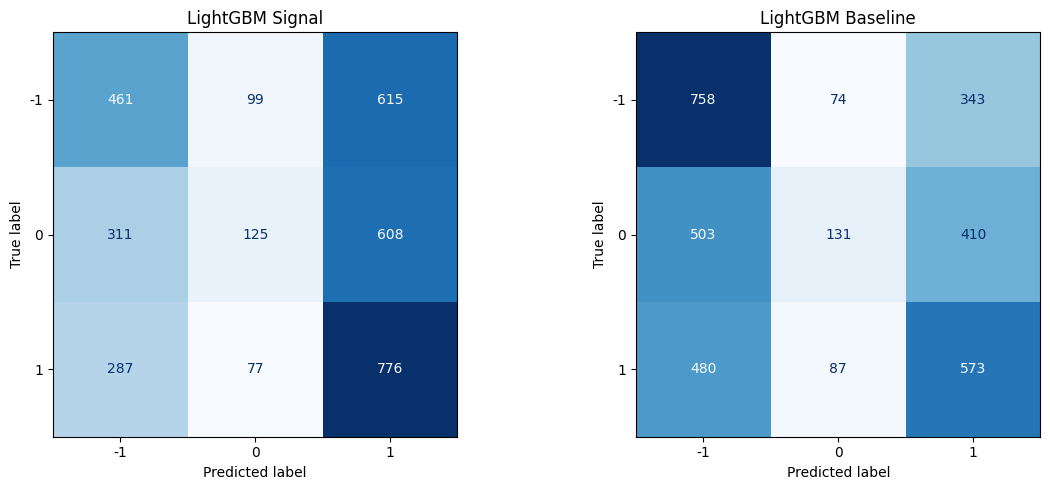

In [28]:
visualization.plot_confusion_matrices(
    models_dict={
        "LightGBM Signal": (signal_best_lgbm, test_signal_X),
        "LightGBM Baseline": (baseline_best_lgbm, test_baseline_X),
    },
    y_test=y_test_signal,
    label_encoder=label_encoder,
)


,Total Return,Average Return,Volatility,Sharpe (annualised),Sortino (annualised),Max Drawdown,Win Rate (%),Number of Trades
Strategy,,,,,,,,
LightGBM Signal (with news),5630.51,1.676246,32.616258,4.810117,8.719883,-2702.38,50.209330,3344
LightGBM Baseline (price-only),14382.82,4.281876,32.390261,12.372904,18.837496,-1124.84,57.082707,3325
Naive Buy-DA/Sell-Spot,4722.73,1.405993,32.658181,4.029426,7.270491,-2730.96,49.717009,3357


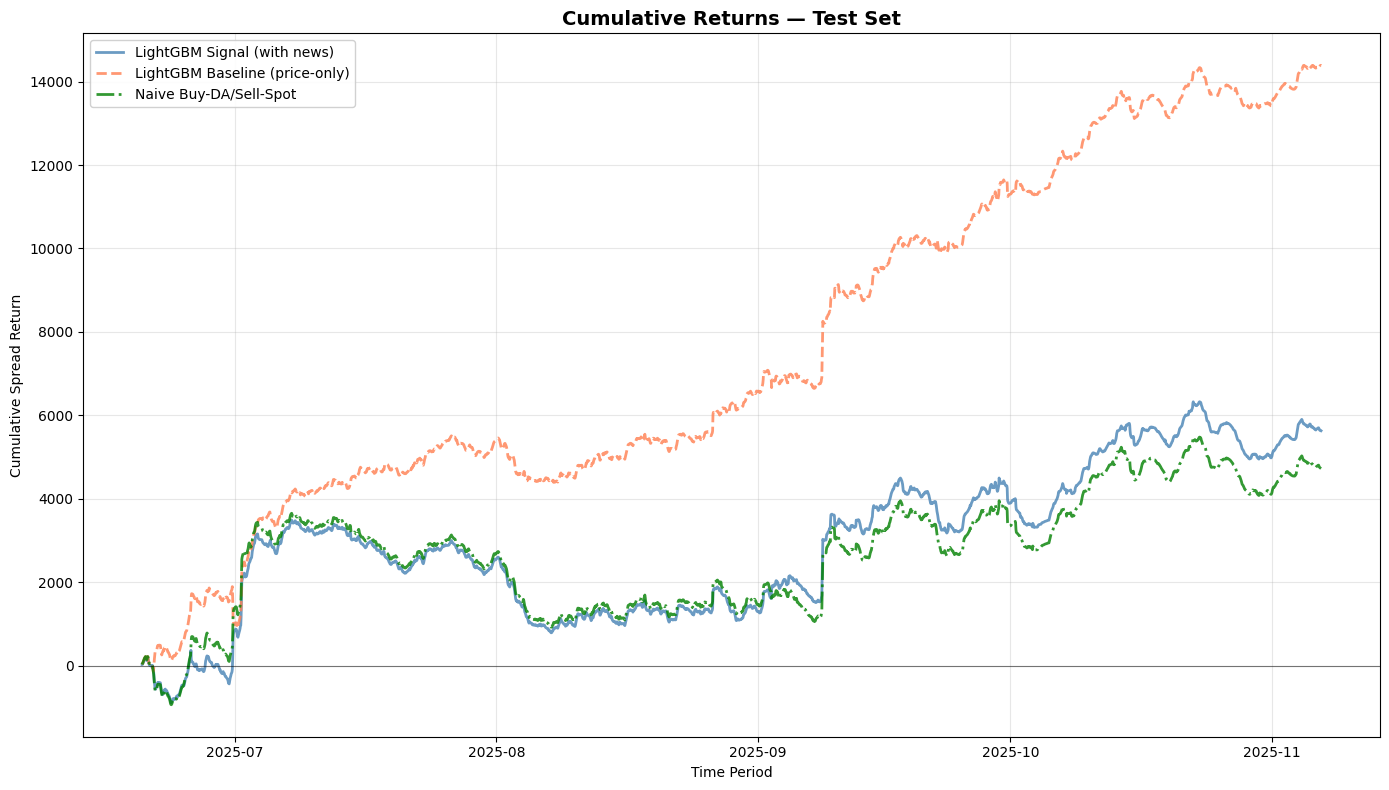

(<Figure size 1400x800 with 1 Axes>,
 <Axes: title={'center': 'Cumulative Returns — Test Set'}, xlabel='Time Period', ylabel='Cumulative Spread Return'>)

In [29]:
spot_col = evaluation.get_column_name([
    "Spot Price", "spot_price", "SpotPrice"
], signal_test_df)
day_ahead_col = evaluation.get_column_name([
    "Day Ahead Auction", "day_ahead_price", "DayAhead"
], signal_test_df)

if spot_col is None or day_ahead_col is None:
    raise KeyError("Could not identify spot or day-ahead price columns for backtesting.")

spot_series = signal_test_df[spot_col]
day_ahead_series = signal_test_df[day_ahead_col]
spread_series = spot_series - day_ahead_series

strategy_actions = {
    "LightGBM Signal (with news)": signal_test_decoded,
    "LightGBM Baseline (price-only)": baseline_test_decoded,
    "Naive Buy-DA/Sell-Spot": np.ones_like(signal_test_decoded, dtype=int),
}

strategy_returns = evaluation.compute_strategy_returns(strategy_actions, spread_series)
returns_summary = evaluation.summarise_strategy_set(strategy_returns)

display(returns_summary)

# Plot cumulative returns
visualization.plot_cumulative_returns(
    returns_map=strategy_returns,
    title="Cumulative Returns — Test Set",
    ylabel="Cumulative Spread Return",
)


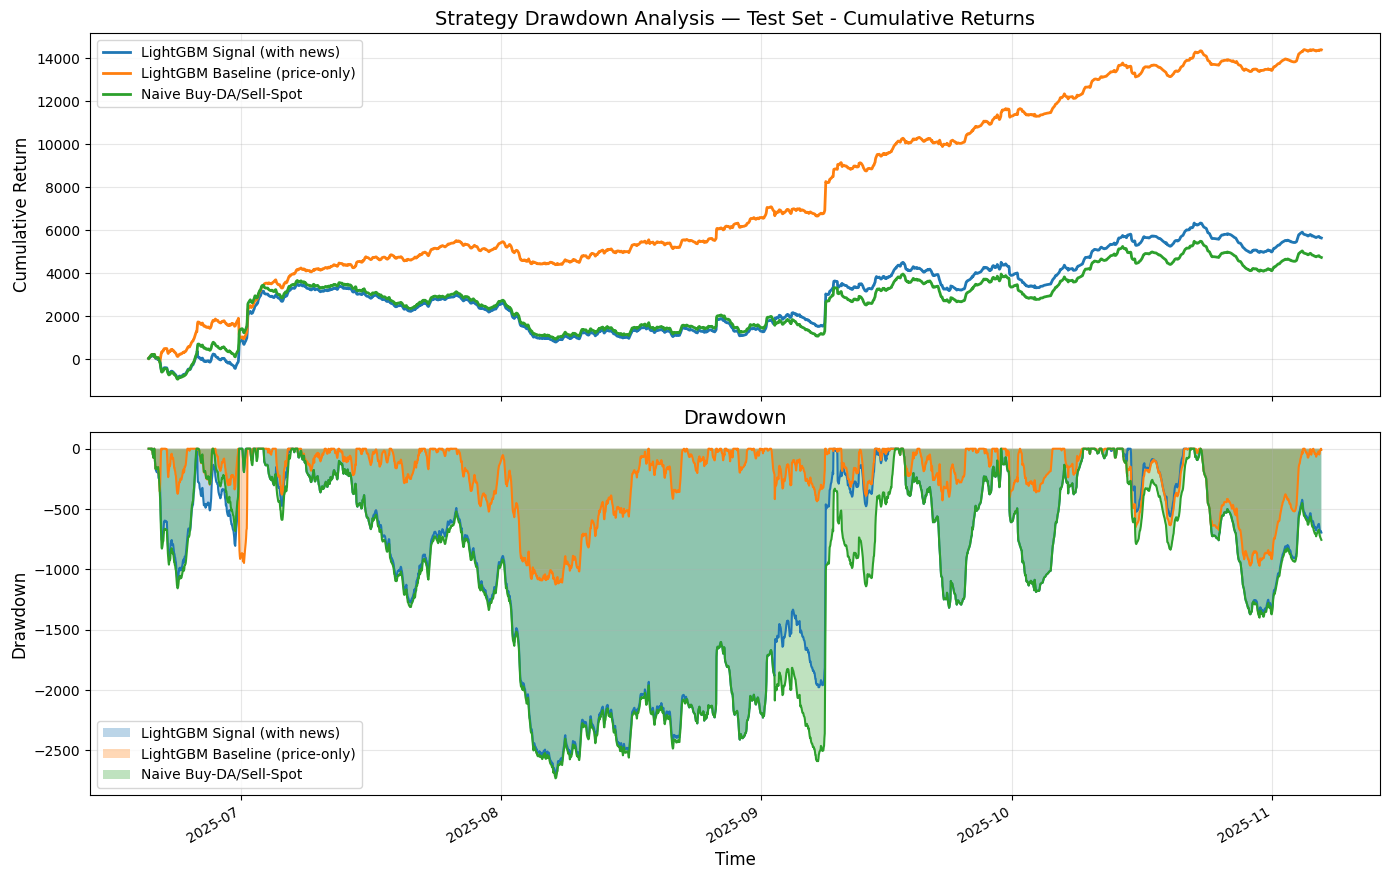

In [30]:
# Plot drawdown analysis
visualization.plot_drawdown_chart(
    returns_map=strategy_returns,
    title="Strategy Drawdown Analysis — Test Set"
)


,Total Return,Average Return,Volatility,Sharpe (annualised),Sortino (annualised),Max Drawdown,Win Rate (%),Number of Trades
Strategy,,,,,,,,
LightGBM Signal (with news),5630.51,1.676246,32.616258,4.810117,8.719883,-2702.38,50.209330,3344
LightGBM Baseline (price-only),14382.82,4.281876,32.390261,12.372904,18.837496,-1124.84,57.082707,3325
Naive Buy-DA/Sell-Spot,4722.73,1.405993,32.658181,4.029426,7.270491,-2730.96,49.717009,3357


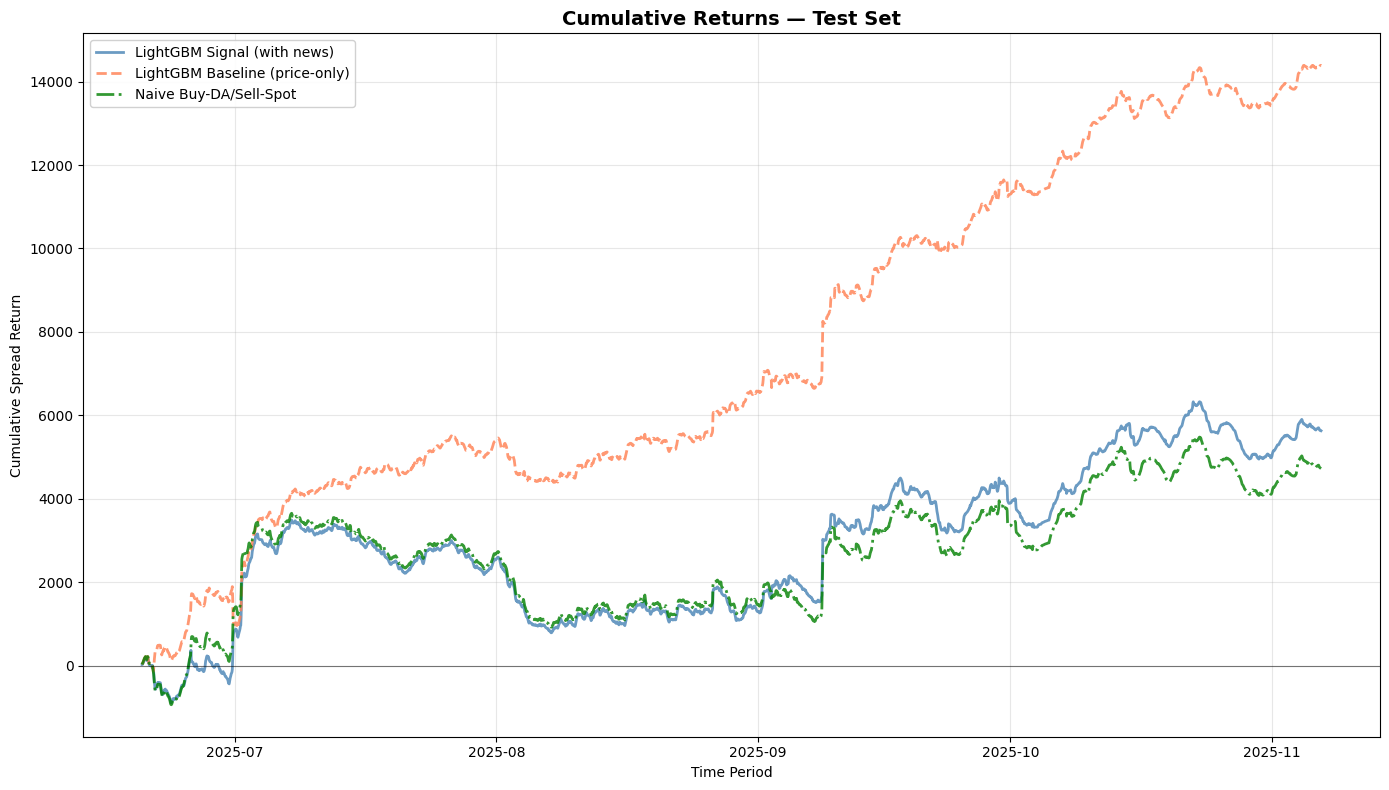

(<Figure size 1400x800 with 1 Axes>,
 <Axes: title={'center': 'Cumulative Returns — Test Set'}, xlabel='Time Period', ylabel='Cumulative Spread Return'>)

In [31]:
# Setup backtest strategies
spread_series, strategy_actions = evaluation.setup_backtest_strategies(
    test_df=signal_test_df,
    signal_predictions=signal_test_pred,
    baseline_predictions=baseline_test_pred,
    label_encoder=label_encoder
)

# Compute and display strategy returns
strategy_returns = evaluation.compute_strategy_returns(strategy_actions, spread_series)
returns_summary = evaluation.summarise_strategy_set(strategy_returns)
display(returns_summary)

# Plot cumulative returns
visualization.plot_cumulative_returns(
    returns_map=strategy_returns,
    title="Cumulative Returns — Test Set",
    ylabel="Cumulative Spread Return",
)


BACKTESTING WITH TRANSACTION COSTS

No Costs:
  Fixed: €0.0/MWh, Percentage: 0.00%

                                Total Return  Sharpe (annualised)  Sortino (annualised)
Strategy                                                                               
LightGBM Signal (with news)          5630.51             4.810117              8.719883
LightGBM Baseline (price-only)      14382.82            12.372904             18.837496
Naive Buy-DA/Sell-Spot               4722.73             4.029426              7.270491

Low Cost (€0.5/MWh):
  Fixed: €0.5/MWh, Percentage: 0.00%

                                Total Return  Sharpe (annualised)  Sortino (annualised)
Strategy                                                                               
LightGBM Signal (with news)          3957.51             3.380890              6.140760
LightGBM Baseline (price-only)      12719.82            10.942506             16.758461
Naive Buy-DA/Sell-Spot               3043.23             2.5964

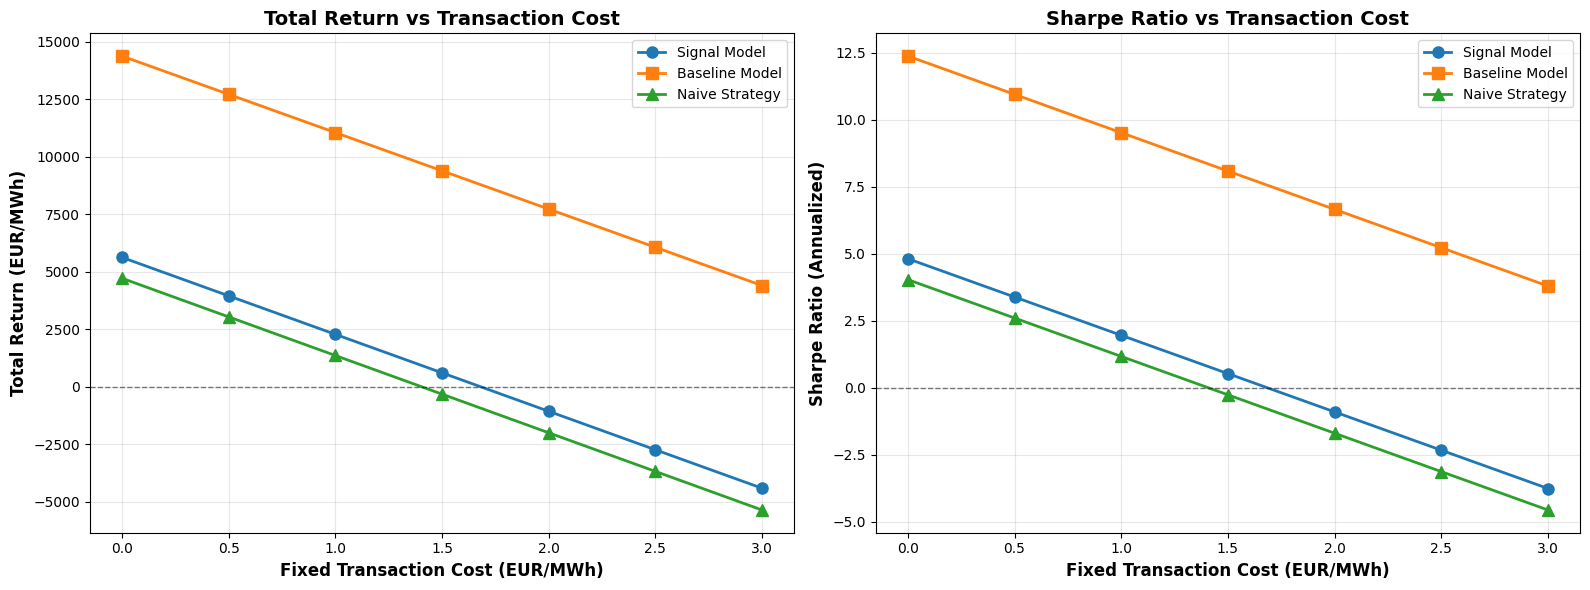

In [32]:
# Evaluate strategies with transaction costs
print("\n" + "=" * 80)
print("BACKTESTING WITH TRANSACTION COSTS")
print("=" * 80)

# Define transaction cost scenarios
transaction_cost_scenarios = {
    "No Costs": (0.0, 0.0),
    "Low Cost (€0.5/MWh)": (0.5, 0.0),
    "Medium Cost (€1.0/MWh)": (1.0, 0.0),
    "High Cost (€2.0/MWh + 0.1%)": (2.0, 0.001),
}

# Compute returns for each scenario
for scenario_name, (fixed_cost, pct_cost) in transaction_cost_scenarios.items():
    print(f"\n{scenario_name}:")
    print(f"  Fixed: €{fixed_cost}/MWh, Percentage: {pct_cost*100:.2f}%")
    
    strategy_returns_cost = evaluation.compute_strategy_returns(
        action_map=strategy_actions,
        spread=spread_series,
        transaction_cost=fixed_cost,
        transaction_cost_pct=pct_cost
    )
    
    returns_summary_cost = evaluation.summarise_strategy_set(strategy_returns_cost)
    print(f"\n{returns_summary_cost[['Total Return', 'Sharpe (annualised)', 'Sortino (annualised)']].to_string()}")

# Visualize impact of transaction costs
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Left: Total return vs transaction cost
costs = [0.0, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0]
signal_returns = []
baseline_returns = []
naive_returns = []

for cost in costs:
    temp_returns = evaluation.compute_strategy_returns(
        action_map=strategy_actions,
        spread=spread_series,
        transaction_cost=cost,
        transaction_cost_pct=0.0
    )
    signal_returns.append(temp_returns["LightGBM Signal (with news)"].sum())
    baseline_returns.append(temp_returns["LightGBM Baseline (price-only)"].sum())
    naive_returns.append(temp_returns["Naive Buy-DA/Sell-Spot"].sum())

ax1.plot(costs, signal_returns, 'o-', linewidth=2, markersize=8, label='Signal Model')
ax1.plot(costs, baseline_returns, 's-', linewidth=2, markersize=8, label='Baseline Model')
ax1.plot(costs, naive_returns, '^-', linewidth=2, markersize=8, label='Naive Strategy')
ax1.axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.5)
ax1.set_xlabel('Fixed Transaction Cost (EUR/MWh)', fontweight='bold', fontsize=12)
ax1.set_ylabel('Total Return (EUR/MWh)', fontweight='bold', fontsize=12)
ax1.set_title('Total Return vs Transaction Cost', fontweight='bold', fontsize=14)
ax1.legend(loc='best')
ax1.grid(alpha=0.3)

# Right: Sharpe ratio vs transaction cost
signal_sharpes = []
baseline_sharpes = []
naive_sharpes = []

for cost in costs:
    temp_returns = evaluation.compute_strategy_returns(
        action_map=strategy_actions,
        spread=spread_series,
        transaction_cost=cost,
        transaction_cost_pct=0.0
    )
    temp_summary = evaluation.summarise_strategy_set(temp_returns)
    signal_sharpes.append(temp_summary.loc["LightGBM Signal (with news)", "Sharpe (annualised)"])
    baseline_sharpes.append(temp_summary.loc["LightGBM Baseline (price-only)", "Sharpe (annualised)"])
    naive_sharpes.append(temp_summary.loc["Naive Buy-DA/Sell-Spot", "Sharpe (annualised)"])

ax2.plot(costs, signal_sharpes, 'o-', linewidth=2, markersize=8, label='Signal Model')
ax2.plot(costs, baseline_sharpes, 's-', linewidth=2, markersize=8, label='Baseline Model')
ax2.plot(costs, naive_sharpes, '^-', linewidth=2, markersize=8, label='Naive Strategy')
ax2.axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.5)
ax2.set_xlabel('Fixed Transaction Cost (EUR/MWh)', fontweight='bold', fontsize=12)
ax2.set_ylabel('Sharpe Ratio (Annualized)', fontweight='bold', fontsize=12)
ax2.set_title('Sharpe Ratio vs Transaction Cost', fontweight='bold', fontsize=14)
ax2.legend(loc='best')
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "=" * 80)

# Feature importance for both models
visualization.plot_feature_importance(model=signal_best_lgbm, feature_names=signal_feature_columns_sanitized, model_name="LightGBM Signal Model", top_n=20)
visualization.plot_feature_importance(model=baseline_best_lgbm, feature_names=baseline_feature_columns_sanitized, model_name="LightGBM Baseline Model", top_n=20)


BACKTESTING WITH TRANSACTION COSTS

No Costs:
  Fixed: €0.0/MWh, Percentage: 0.00%

                                Total Return  Sharpe (annualised)  Sortino (annualised)
Strategy                                                                               
LightGBM Signal (with news)          5630.51             4.810117              8.719883
LightGBM Baseline (price-only)      14382.82            12.372904             18.837496
Naive Buy-DA/Sell-Spot               4722.73             4.029426              7.270491

Low Cost (€0.5/MWh):
  Fixed: €0.5/MWh, Percentage: 0.00%

                                Total Return  Sharpe (annualised)  Sortino (annualised)
Strategy                                                                               
LightGBM Signal (with news)          3957.51             3.380890              6.140760
LightGBM Baseline (price-only)      12719.82            10.942506             16.758461
Naive Buy-DA/Sell-Spot               3043.23             2.5964

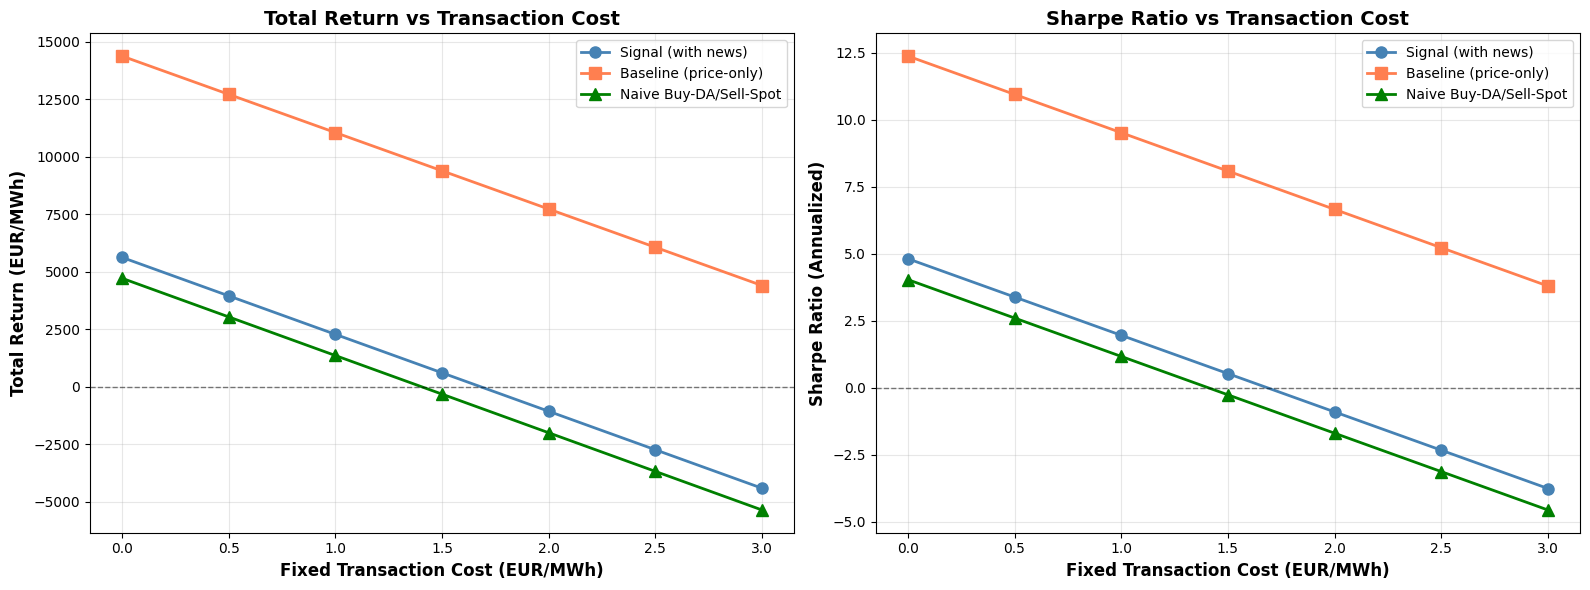

In [33]:
# Transaction cost sensitivity analysis
visualization.plot_transaction_cost_sensitivity(
    strategy_actions=strategy_actions,
    spread_series=spread_series
)